In [12]:
# Gestion des fichiers et dossiers
import os
import zipfile
import random
from google.colab import drive


# Calcul scientifique et manipulation des tableaux
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns #afficher la matrice de confusion plus lisible

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Évaluation du modèle
from sklearn.metrics import classification_report, confusion_matrix


In [13]:
# Nom du dossier et du fichier zip dans Drive
nom_dossier_drive = 'Projet_CNN'
nom_fichier_zip = 'Dataset.zip'

# Dossier local rapide
dossier_extraction = '/content/dataset'

print("Connexion à Google Drive...")
drive.mount('/content/drive')

# Chemin complet du zip
chemin_zip = f'/content/drive/MyDrive/{nom_dossier_drive}/{nom_fichier_zip}'

# Vérification et extraction
if os.path.exists(chemin_zip):
    print("Dataset trouvé")

    if not os.path.exists(dossier_extraction):
        print("Extraction du dataset...")
        with zipfile.ZipFile(chemin_zip, 'r') as zip_ref:
            zip_ref.extractall(dossier_extraction)
        print("Extraction terminée")
    else:
        print("Dataset déjà extrait")
else:
    print("Fichier introuvable")


Connexion à Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset trouvé
Dataset déjà extrait


In [14]:
# DÉTECTION DES DOSSIERS TRAIN / TEST

train_dir, test_dir = None, None

for root, dirs, files in os.walk(dossier_extraction):
    for d in dirs:
        if d.lower() in ['train', 'training']:
            train_dir = os.path.join(root, d)
        elif d.lower() in ['test', 'testing', 'validation']:
            test_dir = os.path.join(root, d)

print("Train :", train_dir)
print("Test  :", test_dir)


Train : /content/dataset/Dataset/Training
Test  : /content/dataset/Dataset/Testing


In [15]:
# --- Paramètres ---
# MobileNetV2 fonctionne de manière optimale avec 224x224
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32    #32 images envoyées à la fois
EPOCHS = 10

print(f"Configuration définie : Images {IMG_WIDTH}x{IMG_HEIGHT}, Batch {BATCH_SIZE}, Epoques {EPOCHS}")

Configuration définie : Images 224x224, Batch 32, Epoques 10


In [16]:

# --- Générateur pour l'entraînement (AVEC Data Augmentation) ---

train_datagen = ImageDataGenerator(
    rescale=1./255,        # convertit les valeurs des pixels (0–255) en 0–1 (normalisation)
    rotation_range=20,     # Rotation aléatoire
    width_shift_range=0.1, # Décalage largeur
    height_shift_range=0.1,# Décalage hauteur
    shear_range=0.1,       # Cisaillement
    zoom_range=0.1,        # Zoom
    horizontal_flip=True,  # Miroir
    fill_mode='nearest',   # Gestion des pixels vides
    # ce sont des transformations aléatoires sur les images, pour créer des variantes.
    validation_split=0.2   # on réserve 20% des images d’entraînement pour valider le modèle pendant l’entraînement
)

# --- Générateur pour le test (SANS Data Augmentation) ---
# On ne modifie jamais les images de test, on les normalise juste.
test_datagen = ImageDataGenerator(rescale=1./255)
print("Générateurs configurés.")

# --- 1. Chargement des images d'entraînement (80%) ---
print("--- Chargement Entraînement ---")
#lit les images, les redimensionne, les normalise, les transforme, les envoie au CNN
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT), # Redimensionne tout à 224x224
    batch_size=BATCH_SIZE, # 32 images à la fois
    class_mode='binary', # classification binaire (tumeur / sain)
    subset='training',#80 % pour apprendre.
)

# --- 2. Chargement des images de validation (20%) ---
print("\n--- Chargement Validation ---")
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',#20 % pour vérifier les performances.
)

# --- 3. Chargement des images de test (Dossier Testing) ---
if os.path.exists(test_dir):
    print("\n--- Chargement Test ---")
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False # Important pour la matrice de confusion à la fin
    )
else:
    print(f"\n⚠️ Attention : Le dossier {test_dir} n'existe pas.")

Générateurs configurés.
--- Chargement Entraînement ---
Found 6622 images belonging to 2 classes.

--- Chargement Validation ---
Found 1655 images belonging to 2 classes.

--- Chargement Test ---
Found 1816 images belonging to 2 classes.


Exemples d'images générées (avec déformations aléatoires) :


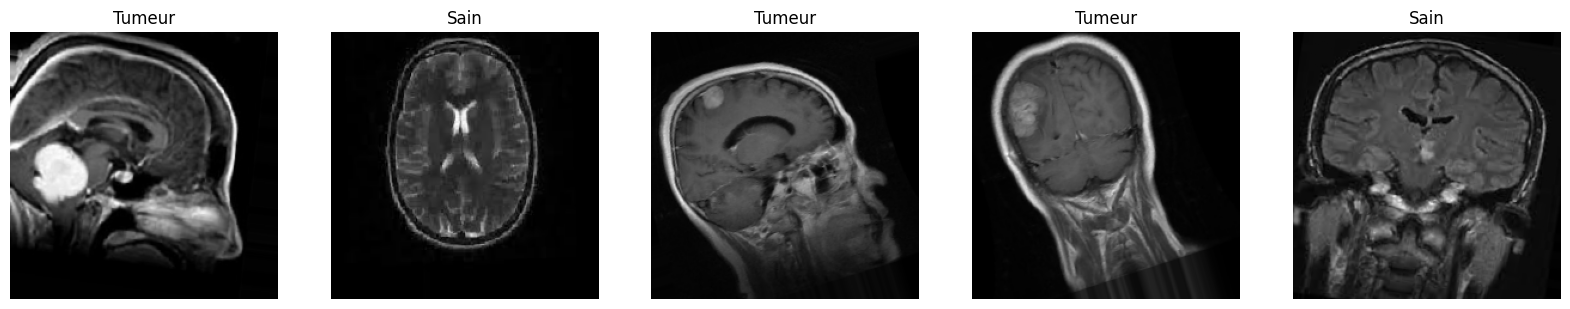

In [18]:

# 1. On demande au générateur un lot d'images (batch)
# La fonction next() déclenche la génération et l'augmentation aléatoire
# tu demandes au générateur “donne-moi un lot d’images préparées pour le CNN”.
# Le générateur applique les transformations aléatoires pour que ton modèle voie des variantes différentes à chaque itération.
images_augmentees, labels = next(train_generator)

# 2. Créer une figure pour afficher les 5 premières images du lot
plt.figure(figsize=(20, 10)) # largeur 20 unités, hauteur 10 unités

print("Exemples d'images générées (avec déformations aléatoires) :")

for i in range(5):
    ax = plt.subplot(1, 5, i + 1) # Crée une grille 1 ligne × 5 colonnes et place chaque image dans une cellule.
    plt.imshow(images_augmentees[i])

    # On affiche le label (0 = Pas de tumeur, 1 = Tumeur)
    status = "Tumeur" if labels[i] == 1 else "Sain" # affiche le label de l’image
    plt.title(status)
    plt.axis("off")

plt.show()

In [19]:

print("\n--- Construction du modèle MobileNetV2 ---")

# A. Charger la base MobileNetV2 (Le "Cerveau" pré-entraîné)
base_model = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),#3 canneaux
                         include_top=False,# On retire la couche finale (les 1000 classes d'ImageNet)
                         weights='imagenet')# On charge les poids déjà appris sur ImageNet

# B. "Geler" le modèle de base (Freezing)
base_model.trainable = False#  ON BLOQUE L'APPRENTISSAGE des couches MobileNet

# C. Ajouter notre tête personnalisée
x = base_model.output #une carte de caractéristiques
x = GlobalAveragePooling2D()(x) # Résume les caractéristiques (plus efficace que Flatten)
x = Dropout(0.2)(x)             # Éteint 20% des neurones pour éviter le surapprentissage
predictions = Dense(1, activation='sigmoid')(x) # Dense(1) = 1 neurone de sortie sigmoid= une proba entre 0 et 1

# D. Assembler le modèle complet
model = Model(inputs=base_model.input, outputs=predictions)
#les images 224×224×3 entrent +notre neurone final (sigmoid) donne la décision binaire

# E. Compiler
model.compile(optimizer='adam',#Algorithme qui ajuste les poids pour réduire la perte
              loss='binary_crossentropy',# Fonction de perte pour choix binaire
              metrics=['accuracy'])

print("Modèle MobileNet chargé avec succès !")
model.summary()


--- Construction du modèle MobileNetV2 ---
Modèle MobileNet chargé avec succès !


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
print("Début de l'entraînement (Transfer Learning)...")

# Tu remarqueras que la précision (accuracy) monte très vite vers 90% !
history = model.fit(
    train_generator,
    epochs=EPOCHS,  # 10 époques suffisent souvent avec MobileNet (au lieu de 15 ou 20)
    validation_data=validation_generator
)

Début de l'entraînement (Transfer Learning)...
Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.8475 - loss: 0.3478 - val_accuracy: 0.8689 - val_loss: 0.3348
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.9577 - loss: 0.1318 - val_accuracy: 0.8749 - val_loss: 0.3036
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.9585 - loss: 0.1134 - val_accuracy: 0.8967 - val_loss: 0.2772
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 485s 2s/step - accuracy: 0.9623 - loss: 0.1056 - val_accuracy: 0.9202 - val_loss: 0.2321
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 486s 2s/step - accuracy: 0.9693 - loss: 0.0944 - val_accuracy: 0.9178 - val_loss: 0.2298
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.9718 - loss: 0.0841 - val_accuracy: 0.9166 - val_loss: 0.2330
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.9723 - loss: 0.0872 - val_accuracy: 0.9130 - val_loss: 0.2439
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/st

In [25]:
print("--- ÉVALUATION FINALE ---")

# On s'assure d'utiliser le générateur de test
if 'test_generator' in locals():
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"\n Précision Finale (Accuracy) : {test_acc*100:.2f}%")
    print(f" Perte Finale (Loss) : {test_loss:.4f}")
else:
    print("Erreur : Le test_generator n'est pas chargé.")

--- ÉVALUATION FINALE ---
57/57 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8513 - loss: 0.3343

 Précision Finale (Accuracy) : 93.06%
 Perte Finale (Loss) : 0.1687


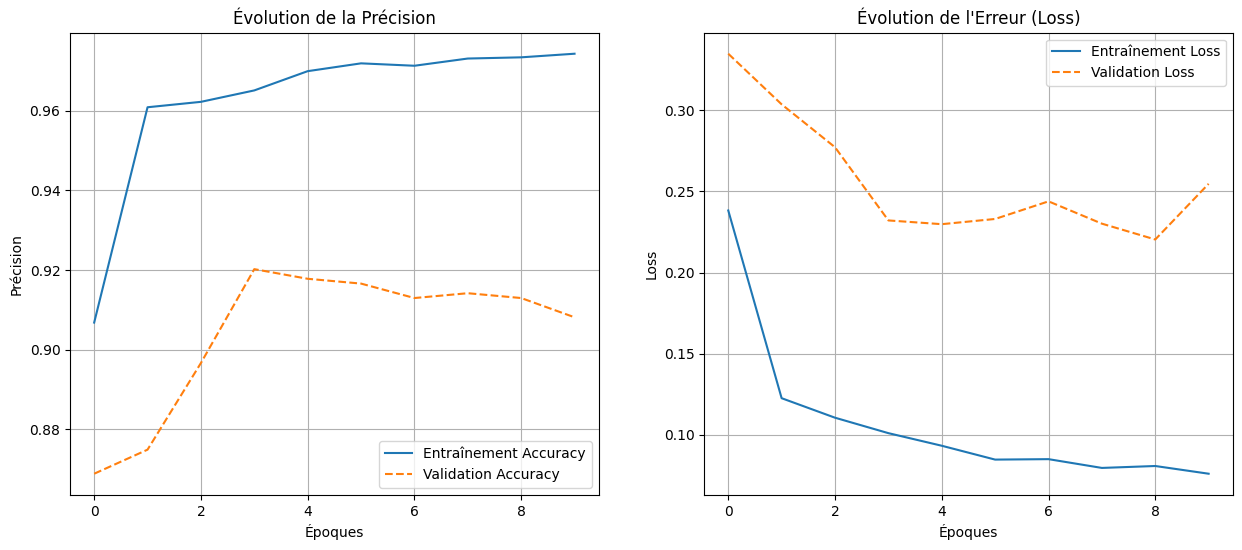

In [22]:
# 5. VISUALISATION DES RÉSULTATS

# --- A. Courbes d'apprentissage ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# --- GRAPHIQUE 1 : PRÉCISION (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
plt.legend(loc='lower right')
plt.title('Évolution de la Précision')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.grid(True)

# --- GRAPHIQUE 2 : PERTE (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
plt.legend(loc='upper right')
plt.title('Évolution de l\'Erreur (Loss)')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.grid(True)

plt.show()


Calcul de la Matrice de Confusion...
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step


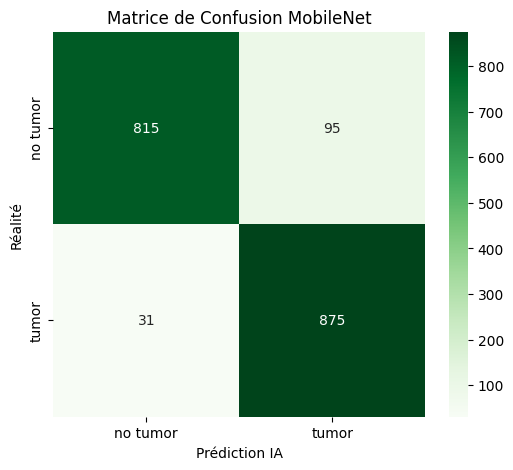

In [23]:
# --- B. Matrice de Confusion ---
print("\nCalcul de la Matrice de Confusion...")
predictions = model.predict(test_generator)# Le modèle fait ses prédictions (probabilités)
predicted_classes = (predictions > 0.5).astype("int32")# Convertit probabilité en 0 ou 1
true_classes = test_generator.classes # Les vraies réponses
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matrice de Confusion MobileNet')
plt.ylabel('Réalité')
plt.xlabel('Prédiction IA')
plt.show()


Test Visuel sur 5 images...


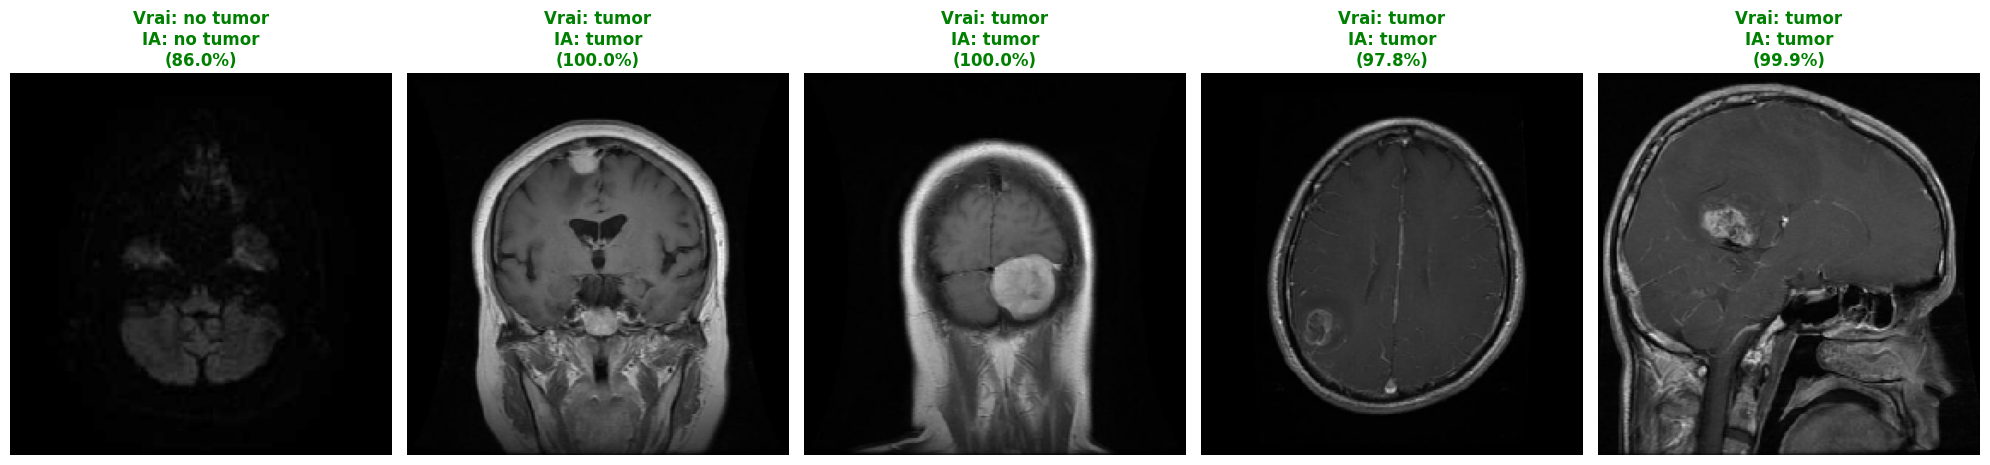

In [24]:
# --- C. Test Visuel sur 5 images aléatoires ---
print("\nTest Visuel sur 5 images...")
class_names = ['no tumor', 'tumor']
plt.figure(figsize=(20, 5))

for i in range(5):
    # Choix aléatoire
    true_label = random.choice(class_names)
    folder_path = os.path.join(test_dir, true_label)
    try:
        random_filename = random.choice(os.listdir(folder_path))
    except: continue

    img_path = os.path.join(folder_path, random_filename)

    # Préparation
    img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT)) # 224x224 !
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Prédiction
    score = model.predict(img_array, verbose=0)[0][0]
    pred_label = 'tumor' if score > 0.5 else 'no tumor'
    prob = score if score > 0.5 else 1 - score

    # Affichage
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"Vrai: {true_label}\nIA: {pred_label}\n({prob*100:.1f}%)", color=color, fontweight='bold')

plt.tight_layout()
plt.show()